In [2]:
import numpy as np
import matplotlib.pyplot as plt

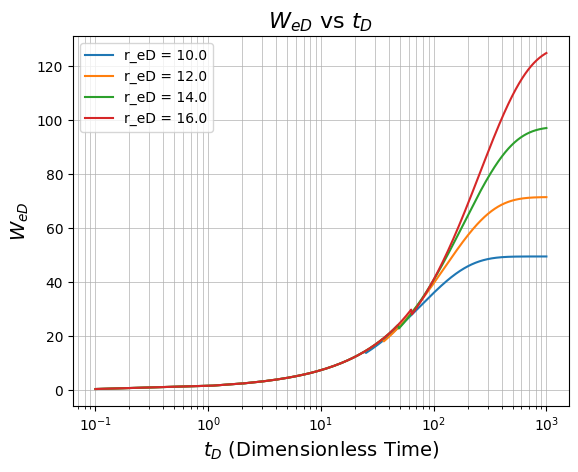

In [4]:
t_D_values = np.arange(0.1,1000,1)
r_eD_values = np.arange(10,16.1,2)

def W_eD(t_D, r_eD):

    if t_D < 0.01:
        return (2 / np.sqrt(np.pi)) * np.sqrt(t_D)

    elif 0.01 <= t_D < 200 and t_D < 0.25 * r_eD**2:
        return (
            (1.12838 * np.sqrt(t_D) + 1.19328 * t_D
                 + 0.269872 * t_D * np.sqrt(t_D)
                + 0.00855294 * t_D**2)
                            /
                (1 + 0.616599 * np.sqrt(t_D)
                 + 0.0413008 * t_D)
        )

    elif t_D > 200 and t_D < 0.25 * r_eD**2:
        return (
            (2.02566 * t_D - 4.29881)
                        /
                np.log(t_D)
        )

    elif t_D > 0.25 * r_eD**2:
        factor_term = (r_eD**2 - 1) / 2
        exp_term = np.exp((-2 * t_D)/(((r_eD**2)-1)*(np.log(r_eD) - 0.75)))
        return factor_term * (1 - exp_term)

    else:
        return np.nan

t_D_vaues = np.logspace(-2, 2, 100)

#r_eD

for r_eD in r_eD_values:
    #print(f"\nCalculations for r_eD = {r_eD:.1f}:")
    W_eD_values = []

    for t_D in t_D_values:
        W_eD_value = W_eD(t_D, r_eD)
        W_eD_values.append(W_eD_value)
        #print(f"t_D = {t_D:.2f}, W_eD = {W_eD_value:.3f}")
    plt.plot(t_D_values, W_eD_values, label=f"r_eD = {r_eD}")

#Plot
plt.xscale('log')
plt.yscale('linear')
plt.xlabel(r"$t_D$ (Dimensionless Time)", fontsize=14)
plt.ylabel(r"$W_{eD}$", fontsize=14)
plt.title(r"$W_{eD}$ vs $t_D$", fontsize=16)
plt.legend()
plt.grid(True, which="both", linestyle="-", linewidth=0.5)
plt.savefig("WeD_vs_tD_plot_2b.png", dpi=300)
plt.show()